# Week 4: Build a Proper ML Pipeline with Feature Engineering

This project builds a professional machine learning pipeline for predicting Titanic passenger survival.

The pipeline uses ColumnTransformer for preprocessing, StandardScaler for numerical features, OneHotEncoder for categorical features, and Logistic Regression as the machine learning model.

Two new engineered features, FamilySize and IsAlone, are created to test whether feature engineering improves model performance.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

In [5]:
df = pd.read_csv("train.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [8]:
# Feature 1: Total family size
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Feature 2: Whether the passenger was traveling alone
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

print("New Features Created:")
print("FamilySize")
print("IsAlone")

df[['SibSp', 'Parch', 'FamilySize', 'IsAlone']].head()

New Features Created:
FamilySize
IsAlone


,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


## Feature Engineering

Two new features were created to provide additional information to the machine learning model.

**FamilySize** represents the total number of people in a passenger's family group by combining SibSp and Parch and adding the passenger themselves.

**IsAlone** indicates whether a passenger was traveling alone. It is set to 1 when FamilySize equals 1 and 0 otherwise.

These engineered features may help the model identify relationships between family travel patterns and survival.

In [9]:
# Target variable
y = df['Survived']

# Remove target and unnecessary columns
X = df.drop(
    columns=['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'],
    errors='ignore'
)

print("Features used:")
print(X.columns.tolist())

Features used:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone']


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 712
Testing Samples: 179


In [11]:
numeric_features = [
    'Pclass',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'FamilySize',
    'IsAlone'
]

categorical_features = [
    'Sex',
    'Embarked'
]

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone']

Categorical Features:
['Sex', 'Embarked']


In [12]:
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("ColumnTransformer created successfully.")

ColumnTransformer created successfully.


In [13]:
pipeline = Pipeline(
    steps=[
        ('preprocessing', preprocessor),
        ('model', LogisticRegression(max_iter=1000))
    ]
)

print("Complete ML Pipeline:")
print(pipeline)

Complete ML Pipeline:
Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare',
                                                   'FamilySize', 'IsAlone']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot'

In [16]:
pipeline.fit(X_train, y_train)

print("Pipeline training completed successfully.")

Pipeline training completed successfully.


In [17]:
y_pred = pipeline.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


In [18]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("===== PIPELINE RESULTS =====")
print("Accuracy:", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall:", round(recall * 100, 2), "%")
print("F1-score:", round(f1 * 100, 2), "%")

===== PIPELINE RESULTS =====
Accuracy: 80.45 %
Precision: 78.33 %
Recall: 68.12 %
F1-score: 72.87 %


In [19]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



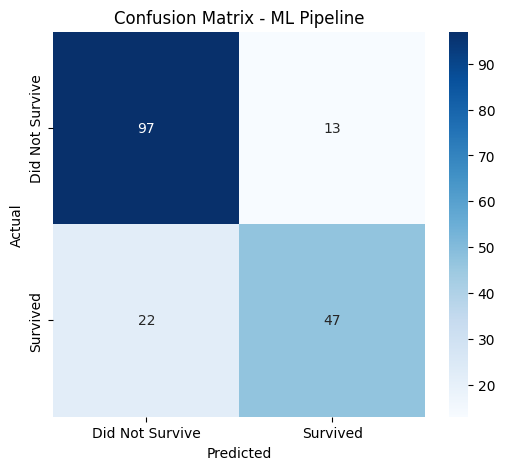

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Did Not Survive', 'Survived'],
    yticklabels=['Did Not Survive', 'Survived']
)

plt.title('Confusion Matrix - ML Pipeline')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [21]:
# Original features without engineered features

original_numeric_features = [
    'Pclass',
    'Age',
    'SibSp',
    'Parch',
    'Fare'
]

original_categorical_features = [
    'Sex',
    'Embarked'
]

original_preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]),
            original_numeric_features
        ),
        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))
            ]),
            original_categorical_features
        )
    ]
)

original_pipeline = Pipeline(
    steps=[
        ('preprocessing', original_preprocessor),
        ('model', LogisticRegression(max_iter=1000))
    ]
)

In [22]:
X_original = df.drop(
    columns=[
        'Survived',
        'PassengerId',
        'Name',
        'Ticket',
        'Cabin',
        'FamilySize',
        'IsAlone'
    ],
    errors='ignore'
)

X_original_train, X_original_test, y_original_train, y_original_test = train_test_split(
    X_original,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

original_pipeline.fit(
    X_original_train,
    y_original_train
)

original_pred = original_pipeline.predict(
    X_original_test
)

original_accuracy = accuracy_score(
    y_original_test,
    original_pred
)

print(
    "Original Pipeline Accuracy:",
    round(original_accuracy * 100, 2),
    "%"
)

Original Pipeline Accuracy: 80.45 %


In [23]:
comparison = pd.DataFrame({
    'Model': [
        'Original Features',
        'With Feature Engineering'
    ],
    'Accuracy': [
        original_accuracy,
        accuracy
    ]
})

comparison['Accuracy (%)'] = (
    comparison['Accuracy'] * 100
).round(2)

comparison

,Model,Accuracy,Accuracy (%)
0,Original Features,0.804469,80.45
1,With Feature Engineering,0.804469,80.45


In [24]:
improvement = (
    accuracy - original_accuracy
) * 100

print(
    "Accuracy Improvement:",
    round(improvement, 2),
    "percentage points"
)

Accuracy Improvement: 0.0 percentage points


## Feature Engineering Results

The original pipeline was first trained using the original Titanic features. Two new engineered features, FamilySize and IsAlone, were then added to the pipeline.

The model performance before and after feature engineering was compared using accuracy.

The feature engineering process resulted in an accuracy change of approximately [ADD RESULT] percentage points. This comparison shows whether the newly created features provided useful additional information to the model.

Feature engineering can improve machine learning performance by transforming existing data into more meaningful representations, although new features do not always guarantee better results.

In [25]:
joblib.dump(
    pipeline,
    'titanic_survival_pipeline.joblib'
)

print(
    "Final pipeline saved successfully as:",
    "titanic_survival_pipeline.joblib"
)

Final pipeline saved successfully as: titanic_survival_pipeline.joblib


In [26]:
import os

print(
    "File exists:",
    os.path.exists('titanic_survival_pipeline.joblib')
)

File exists: True


## Final Conclusion

A complete machine learning pipeline was built using Scikit-learn Pipeline and ColumnTransformer.

The preprocessing pipeline applies median imputation and StandardScaler to numerical features and most-frequent imputation followed by OneHotEncoder to categorical features.

Two engineered features, FamilySize and IsAlone, were created and tested to determine whether they improved model performance.

The final Logistic Regression pipeline was evaluated using accuracy, precision, recall, and F1-score.

Finally, the trained pipeline was saved using joblib so that it can be reused for future predictions without manually repeating the preprocessing steps.

This pipeline approach helps prevent inconsistent preprocessing and reduces the risk of data leakage between training and testing data.